In [2]:
import json
import networkx as nx
import matplotlib.pyplot as plt
import japanize_matplotlib

In [3]:
data_path = "./gpt_v2_simplified.json"

with open(data_path, "r") as f:
    data = json.load(f)

# Create a directed graph using the filtered data
G = nx.DiGraph()  # Directed graph

for entry in data:
    if "drill_task_name" in entry["data"][0] and "drill_task_name" in entry["data"][1]:
        drill_task_name1 = entry["data"][0]["drill_task_name"]
        drill_task_name2 = entry["data"][1]["drill_task_name"]
        result = entry["annotation"]["answer"].lower()
    
        # Add a directed edge from drill_task_name1 to drill_task_name2 if result is "related"
        if result == "related":
            G.add_edge(drill_task_name1, drill_task_name2)
    else:
        print("No drill_task_name in data")

G = nx.transitive_reduction(G)  # Remove redundant edges

In [5]:
# Calculate the mean number of edges per node
mean_edges_per_node = sum(dict(G.out_degree()).values()) / len(G.nodes())
print(f"Mean number of edges per node: {mean_edges_per_node}")

Mean number of edges per node: 1.2173913043478262


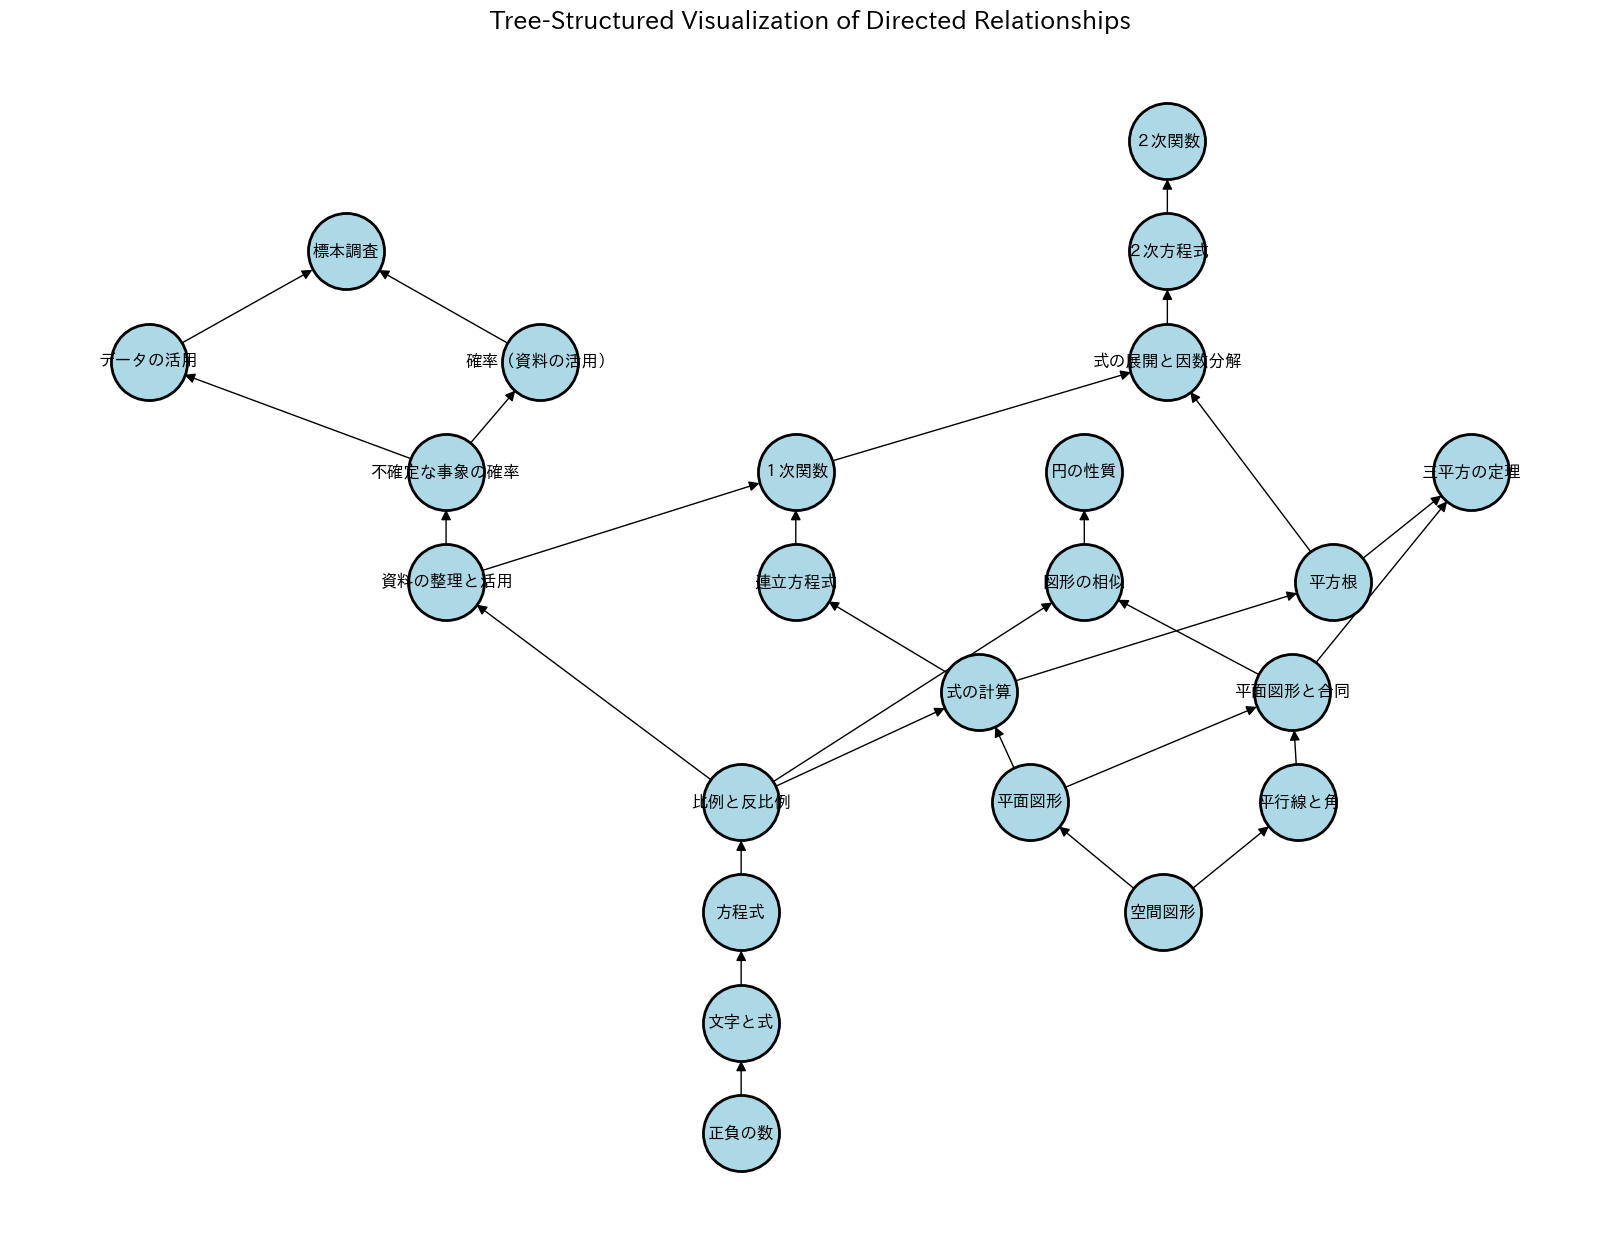

In [19]:
# Ensure the graph is a directed acyclic graph (DAG)
if not nx.is_directed_acyclic_graph(G):
    raise ValueError("The graph is not a directed acyclic graph (DAG) and cannot be visualized as a tree.")

G_reverse = G.reverse()  # Reverse the graph for topological sorting

# Use NetworkX's hierarchy layout for tree visualization
pos = nx.nx_agraph.graphviz_layout(G_reverse, prog="dot")  # 'dot' creates a hierarchical layout

# Visualize the graph as a tree
plt.figure(figsize=(16, 12))
nx.draw(
    G, pos, with_labels=True, arrows=True, arrowstyle='-|>', arrowsize=15,
    node_size=3000, node_color="lightblue", edgecolors="black", linewidths=2, font_family="IPAexGothic"
)
plt.title("Tree-Structured Visualization of Directed Relationships", fontsize=18)
plt.axis("off")
plt.show()